# 第7章　XGBoost

## 7.4　PythonでXGBoost

### コード7.1

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import os

def main():
    # 1. データの読み込みと準備
    wine = load_wine()
    df = pd.DataFrame(wine.data, columns=wine.feature_names)
    df['target'] = wine.target

    # 2. 簡易EDA
    print("--- データの基本情報 ---")
    print(df.info())

    print("\n--- 統計量の確認 ---")
    print(df.describe())

    # 相関行列の可視化と保存
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Matrix')
    plt.savefig('correlation_matrix.svg', format='svg', bbox_inches='tight')
    plt.close() # グラフ表示を抑止し，ファイル保存のみ行う

    # 3. 学習データとテストデータの分割
    X = df.drop('target', axis=1)
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4. GridSearchCVによるハイパーパラメータチューニング
    clf = xgb.XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    )

    param_grid = {
        'n_estimators': [50, 100],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8, 1.0]
    }

    print("\n--- グリッドサーチを開始します ---")
    grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best CV Score: {grid_search.best_score_:.4f}")

    best_model = grid_search.best_estimator_

    # 5. 評価
    y_pred = best_model.predict(X_test)

    print("\n--- テストデータでの評価レポート ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\n詳細レポート:")
    print(classification_report(y_test, y_pred, target_names=wine.target_names))

    # 6. 特徴量重要度の可視化と保存
    plt.figure(figsize=(10, 6))
    xgb.plot_importance(best_model, importance_type='gain')
    plt.title('Feature Importance (Best Model)')
    plt.tight_layout() # レイアウト調整
    plt.savefig('feature_importance.svg', format='svg', bbox_inches='tight')
    plt.close()

    print(f" - correlation_matrix.svg") #ファイルは保存されています
    print(f" - feature_importance.svg") #ファイルは保存されています

if __name__ == "__main__":
    main()

--- データの基本情報 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    f

<Figure size 1000x600 with 0 Axes>

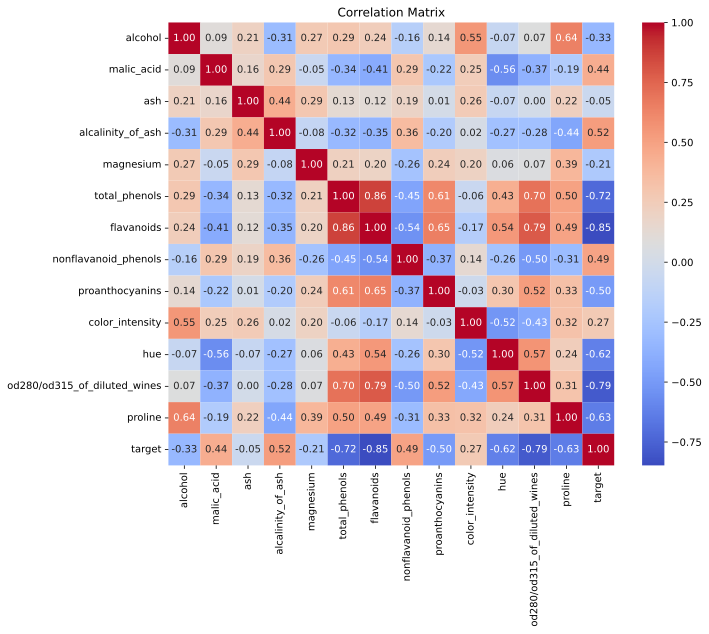

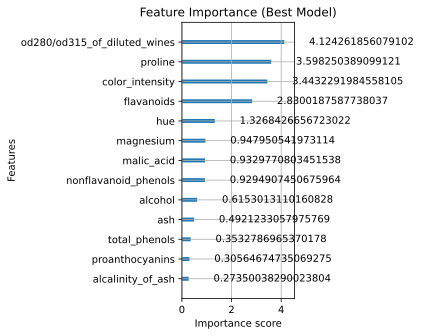

In [ ]:
# 出力された画像を画面に表示する場合は，下記を実行
from IPython.display import *
display_svg(SVG('correlation_matrix.svg'))
display_svg(SVG('feature_importance.svg'))